In [206]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


In [208]:
data = pd.read_csv("C:/Users/Chet/Documents/practice_data.csv")
data.head(20)

,EmployeeID,gender,department,Days Present,Accuracy of Work,Meeting Project Deadlines,Task Completion Rates,Interpersonal Skills Rating,Decision-Making Skills Rating,Sales Revenue Generated,churned
0,1,Male,Sales,20,High,Yes,85,8,7,51638,No
1,2,Female,Marketing,22,Medium,Yes,90,7,6,97797,Yes
2,3,Male,Human Resources,25,High,No,80,9,8,95341,No
3,4,Male,Engineering,19,Low,Yes,75,6,5,91806,No
4,5,Female,Finance,23,Medium,Yes,85,7,7,64247,Yes
5,6,Male,Sales,21,High,Yes,95,8,8,89988,No
6,7,Female,Marketing,24,Low,No,70,5,4,70934,Yes
7,8,Male,Human Resources,18,Medium,Yes,80,6,6,96578,No
8,9,Male,Engineering,20,High,Yes,90,8,7,74219,No
9,10,Female,Finance,22,Medium,Yes,85,7,6,87009,Yes


## selecting K Means 

In [211]:
import os
os.environ["OMP_NUM_THREADS"] = "1"


import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore", category=UserWarning)



In [213]:
# Convert categorical columns to numeric using LabelEncoder
le = LabelEncoder()
data['gender'] = le.fit_transform(data['gender'])  # Male=1, Female=0
data['department'] = le.fit_transform(data['department'])
data['Accuracy of Work'] = le.fit_transform(data['Accuracy of Work'])  # High=0, Low=1, Medium=2
data['Meeting Project Deadlines'] = le.fit_transform(data['Meeting Project Deadlines'])  # Yes=1, No=0
data['churned'] = le.fit_transform(data['churned'])  # No=0, Yes=1


In [215]:
# Drop ID and churn target (you don't want to cluster based on these)
features = data.drop(columns=['EmployeeID', 'churned'])

# Define feature set for clustering
x = features.values


WCSS values for each cluster count (1 to 10):
Clusters: 1, WCSS: 6361678473.612903
Clusters: 2, WCSS: 1767157120.881579
Clusters: 3, WCSS: 585088366.1010101
Clusters: 4, WCSS: 421803323.8333333
Clusters: 5, WCSS: 200099371.73492065
Clusters: 6, WCSS: 143559880.6
Clusters: 7, WCSS: 101344088.21666667
Clusters: 8, WCSS: 62858848.5
Clusters: 9, WCSS: 36387291.75
Clusters: 10, WCSS: 20591985.75


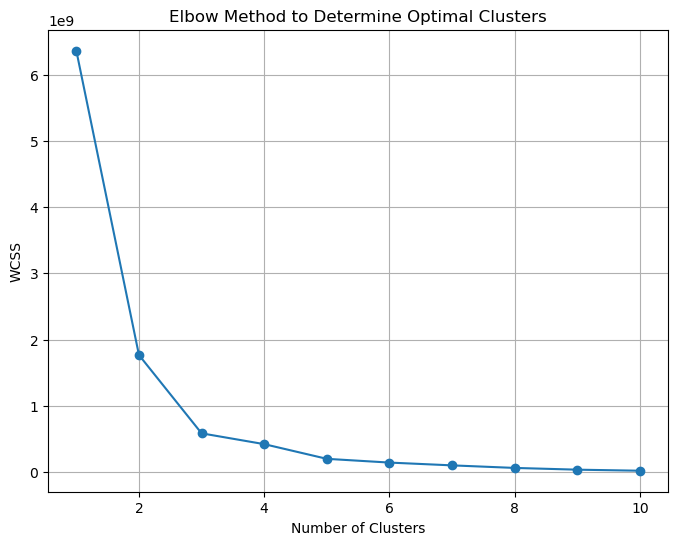

In [217]:
wcss = []

# Calculate WCSS for 1 to 10 clusters
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)

# Print WCSS values
print("WCSS values for each cluster count (1 to 10):")
for i, val in enumerate(wcss, start=1):
    print(f"Clusters: {i}, WCSS: {val}")

# Plot Elbow Curve
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method to Determine Optimal Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()


## Developing K mean

In [222]:

label_encoders = {}
for col in ['gender', 'department', 'Accuracy of Work', 'Meeting Project Deadlines', 'churned']:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le


features = ['gender', 'department', 'Days Present', 'Accuracy of Work',
            'Meeting Project Deadlines', 'Task Completion Rates',
            'Interpersonal Skills Rating', 'Decision-Making Skills Rating',
            'Sales Revenue Generated', 'churned']

x = data[features]

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)


selected_k_value = 3
kmeans = KMeans(n_clusters=selected_k_value, init='k-means++', random_state=42)
kmeans.fit(x_scaled)

labels = kmeans.labels_
print(labels)

data['Cluster'] = labels

print(data[['EmployeeID', 'Cluster']])


[2 0 2 1 2 2 0 0 2 0 2 0 1 2 0 0 2 1 1 0 2 2 1 1 2 0 2 2 1 1 2]
    EmployeeID  Cluster
0            1        2
1            2        0
2            3        2
3            4        1
4            5        2
5            6        2
6            7        0
7            8        0
8            9        2
9           10        0
10          11        2
11          12        0
12          13        1
13          14        2
14          15        0
15          16        0
16          17        2
17          18        1
18          19        1
19          20        0
20          21        2
21          22        2
22          23        1
23          24        1
24          25        2
25          26        0
26          27        2
27          28        2
28          29        1
29          30        1
30          31        2
